# Flood Susceptibility Data Preprocessing Pipeline

This notebook preprocesses flood susceptibility data with the following steps:

1. **Stratified 70/30 split** (to preserve class balance)
2. **Aspect transformation** using `sin` and `cos` due to circular nature
3. **Skewness correction** using `log1p` or **Yeo-Johnson** based on feature values
4. **MinMax Normalization** for continuous features
5. **Categorical features** retained as-is for later use with embedding layers

The test set is **not fitted**, only transformed using training-set parameters to avoid leakage.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

In [ ]:
# Load cleaned dataset
df = pd.read_csv('Cleaned_Flood_Data.csv')

In [ ]:
# Separate features and target
X = df.drop(columns=['f_nf'])
y = df['f_nf']

In [ ]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
# Confirm class distribution
print('Train set:\n', y_train.value_counts())
print('\nTest set:\n', y_test.value_counts())

Train set:
 f_nf
0    99
1    97
Name: count, dtype: int64

Test set:
 f_nf
1    42
0    42
Name: count, dtype: int64


## Aspect Transformation
`aspect` is a circular feature, so applying sine and cosine transformations preserves its cyclical properties.

In [ ]:
aspect_rad_train = np.deg2rad(X_train['aspect'])
aspect_rad_test = np.deg2rad(X_test['aspect'])
X_train['aspect_sin'] = np.sin(aspect_rad_train)
X_train['aspect_cos'] = np.cos(aspect_rad_train)
X_test['aspect_sin'] = np.sin(aspect_rad_test)
X_test['aspect_cos'] = np.cos(aspect_rad_test)
X_train.drop(columns=['aspect'], inplace=True)
X_test.drop(columns=['aspect'], inplace=True)

More details:

Aspect is a standard ingredient of statistical and machine-learning models of Earth surface processes and topoclimatic variables, and in digital soil mapping and ecological modeling (e.g., Brenning et al. 2015; Deluigi, Lambiel, and Kanevski 2017). Unlike other quantitative predictors:

- The distance between 359° and 1° is 2°, not 358°.
- Is 180° greater or smaller than 0° (=360°), or can it be both?
- Two times 180° is 0° (or at least equivalent to 0°).

<br>


**Cosine-sine encoding:**
Cosine and sine of aspect as predictors, making use of the fact that angles can be uniquely represented by their cosine and sine values (Stage 1976; Brenning and Trombotto 2006; Brenning et al. 2015);

<br>

https://geods.netlify.app/post/directional-variables-in-ml-models/

written by Alexander Brenning
Professor of Geographic Information Science

<br>

> additional reference:
 >https://doi.org/10.1038/sdata.2018.40



## Skewness Correction
- Used `log1p` for features that are strictly positive and highly skewed
- Used `Yeo-Johnson` for those that may include zero or negative values

In [ ]:
# Identify continuous and categorical features
categorical_cols = ['land_use', 'lithology', 'soil']
continuous_cols = [col for col in X.columns if col not in categorical_cols + ['aspect', 'aspect_sin', 'aspect_cos']]

In [ ]:
from scipy.stats import skew

# Compute skewness before transformation
skew_before = X_train[continuous_cols].apply(skew).sort_values(ascending=False)

# Display skewness
print("Skewness BEFORE transformation (train set only):")
display(skew_before)

Skewness BEFORE transformation (train set only):


,0
flow_accumulation,12.687192
spi,11.775796
slope,1.567413
tpi,1.300162
dem,1.190055
twi,1.101233
distance_from_river,0.734619
tri,0.099105
rainfall,-0.152376
profile_curvature,-0.211806


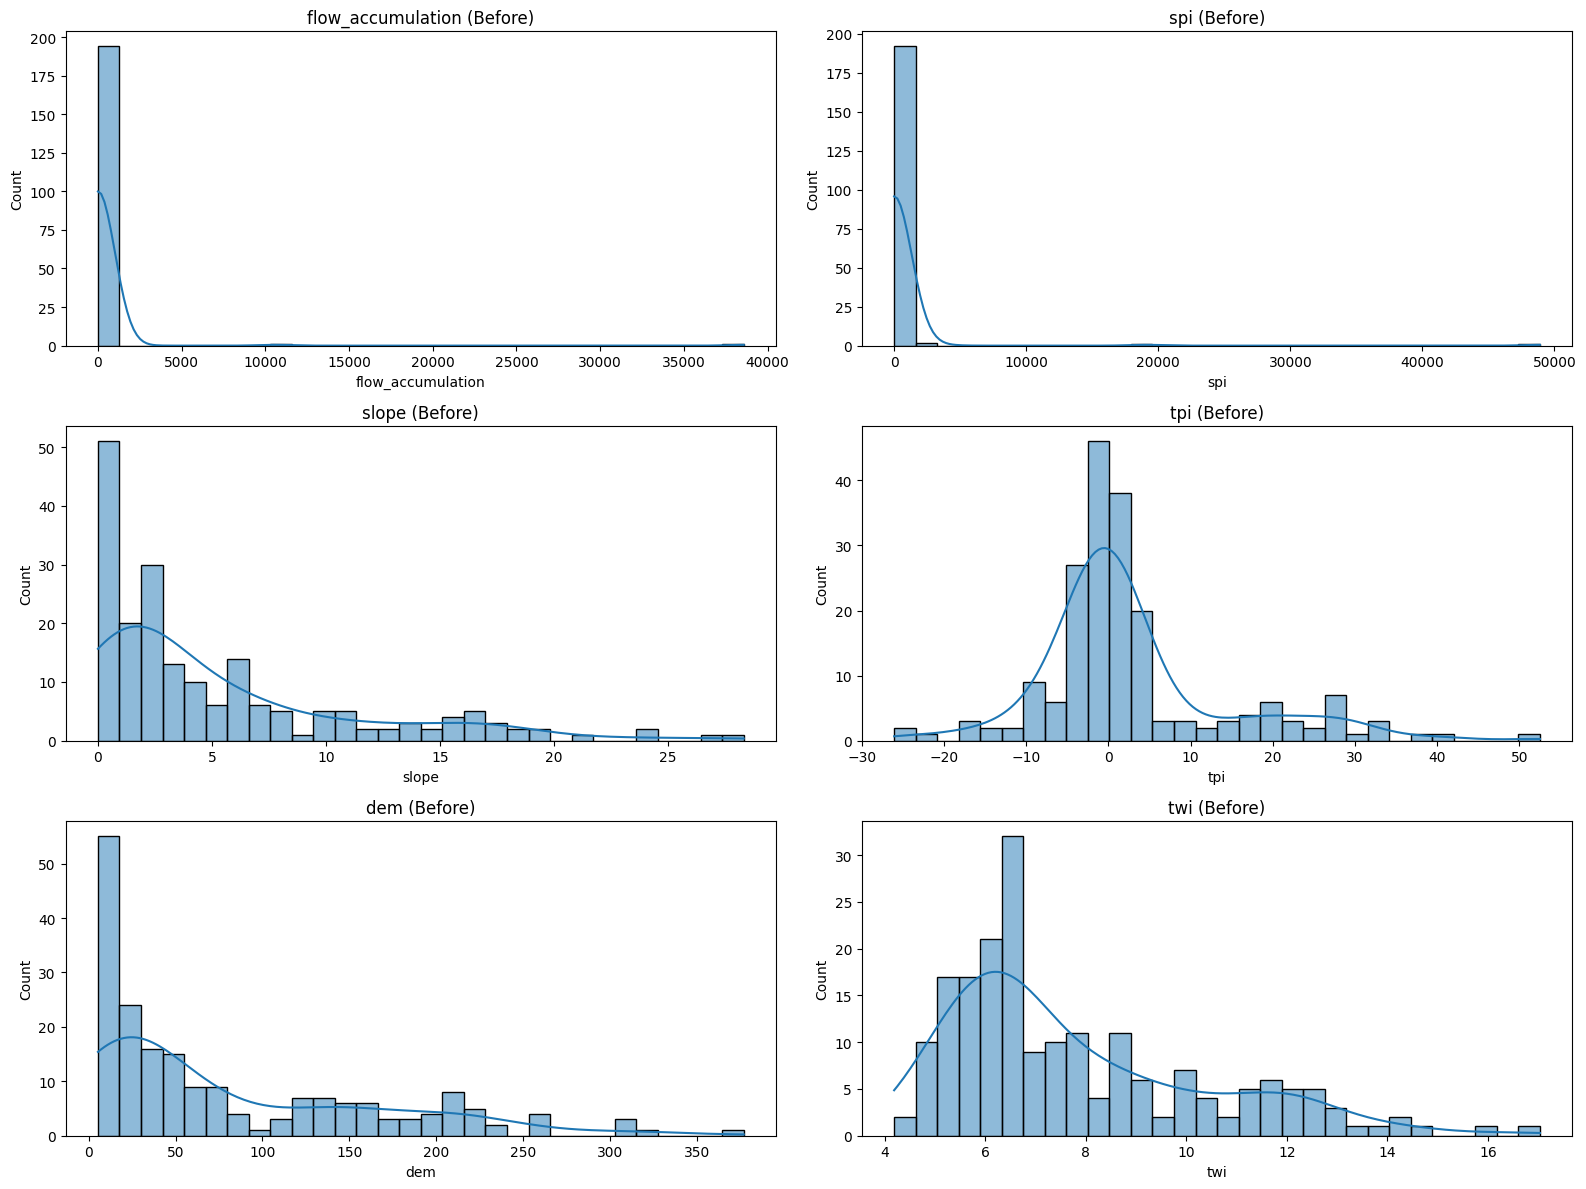

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms of the top 6 most skewed features before transformation
top_skewed_cols = skew_before.head(6).index.tolist()

plt.figure(figsize=(16, 12))
for i, col in enumerate(top_skewed_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(X_train[col], bins=30, kde=True)
    plt.title(f'{col} (Before)')
plt.tight_layout()
plt.show()

In [ ]:
# Select only features with absolute skewness > 1
skewed_cols = skew_before[abs(skew_before) > 1].index.tolist()

print("\nApplying log1p to these highly skewed features:")
print(skewed_cols)


Applying log1p to these highly skewed features:
['flow_accumulation', 'spi', 'slope', 'tpi', 'dem', 'twi']


In [ ]:
# Check for negative values in each skewed column
negatives_check = X_train[skewed_cols].apply(lambda col: (col < 0).any())
print("Columns with negative values:")
display(negatives_check[negatives_check == True])

Columns with negative values:


,0
tpi,True



Apply appropriate transformations to continuous features with high positive skewness to improve their distribution:

- **log1p transformation** (`log(1 + x)`) is used for positively skewed features with all non-negative values. This transformation helps:
  - Reduce skewness
  - Stabilize variance
  - Improve model performance  
  > _"The log transformation is commonly used as a traditional technique to normalize skewed data."_  
  > — **Hammouri et al. (2020)**, *Applied Sciences*, MDPI
  
    > https://doi.org/10.3390/app10186247

- **Yeo–Johnson transformation** is applied to features that contain **negative values**, specifically `tpi`. Unlike log1p, Yeo–Johnson supports both positive and negative values.



In [ ]:
log1p_cols = ['dem', 'flow_accumulation', 'slope', 'spi', 'twi']
yeojohnson_cols = ['tpi']  # since it has negatives

In [ ]:
from sklearn.preprocessing import PowerTransformer

# Apply skewness correction
for col in log1p_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

pt = PowerTransformer(method='yeo-johnson')
if yeojohnson_cols:
    X_train[yeojohnson_cols] = pt.fit_transform(X_train[yeojohnson_cols])
    X_test[yeojohnson_cols] = pt.transform(X_test[yeojohnson_cols])

In [ ]:
# Combine the transformed features into one DataFrame
transformed_train = pd.concat([
    X_train[log1p_cols],
    pd.DataFrame(X_train[yeojohnson_cols], columns=yeojohnson_cols, index=X_train.index)
], axis=1)

# Compute skewness after transformation
skew_after = transformed_train.apply(skew).sort_values(ascending=False)

print("Skewness AFTER transformation (train set only):")
display(skew_after)

Skewness AFTER transformation (train set only):


,0
flow_accumulation,2.341177
spi,1.872014
twi,0.642100
slope,0.185595
dem,0.067400
tpi,-0.328423


In [ ]:
# Combine all transformed columns
all_transformed_cols = log1p_cols + yeojohnson_cols

# Check for NaNs in each column of the training set
nan_check = X_train[all_transformed_cols].isna().sum()

# Display only columns with NaNs (if any)
print("NaN values in transformed columns (train set):")
display(nan_check[nan_check > 0])

NaN values in transformed columns (train set):


,0


In [ ]:
# Check for NaNs in test set transformed columns
nan_check_test = X_test[all_transformed_cols].isna().sum()

print("NaN values in transformed columns (test set):")
display(nan_check_test[nan_check_test > 0])

NaN values in transformed columns (test set):


,0


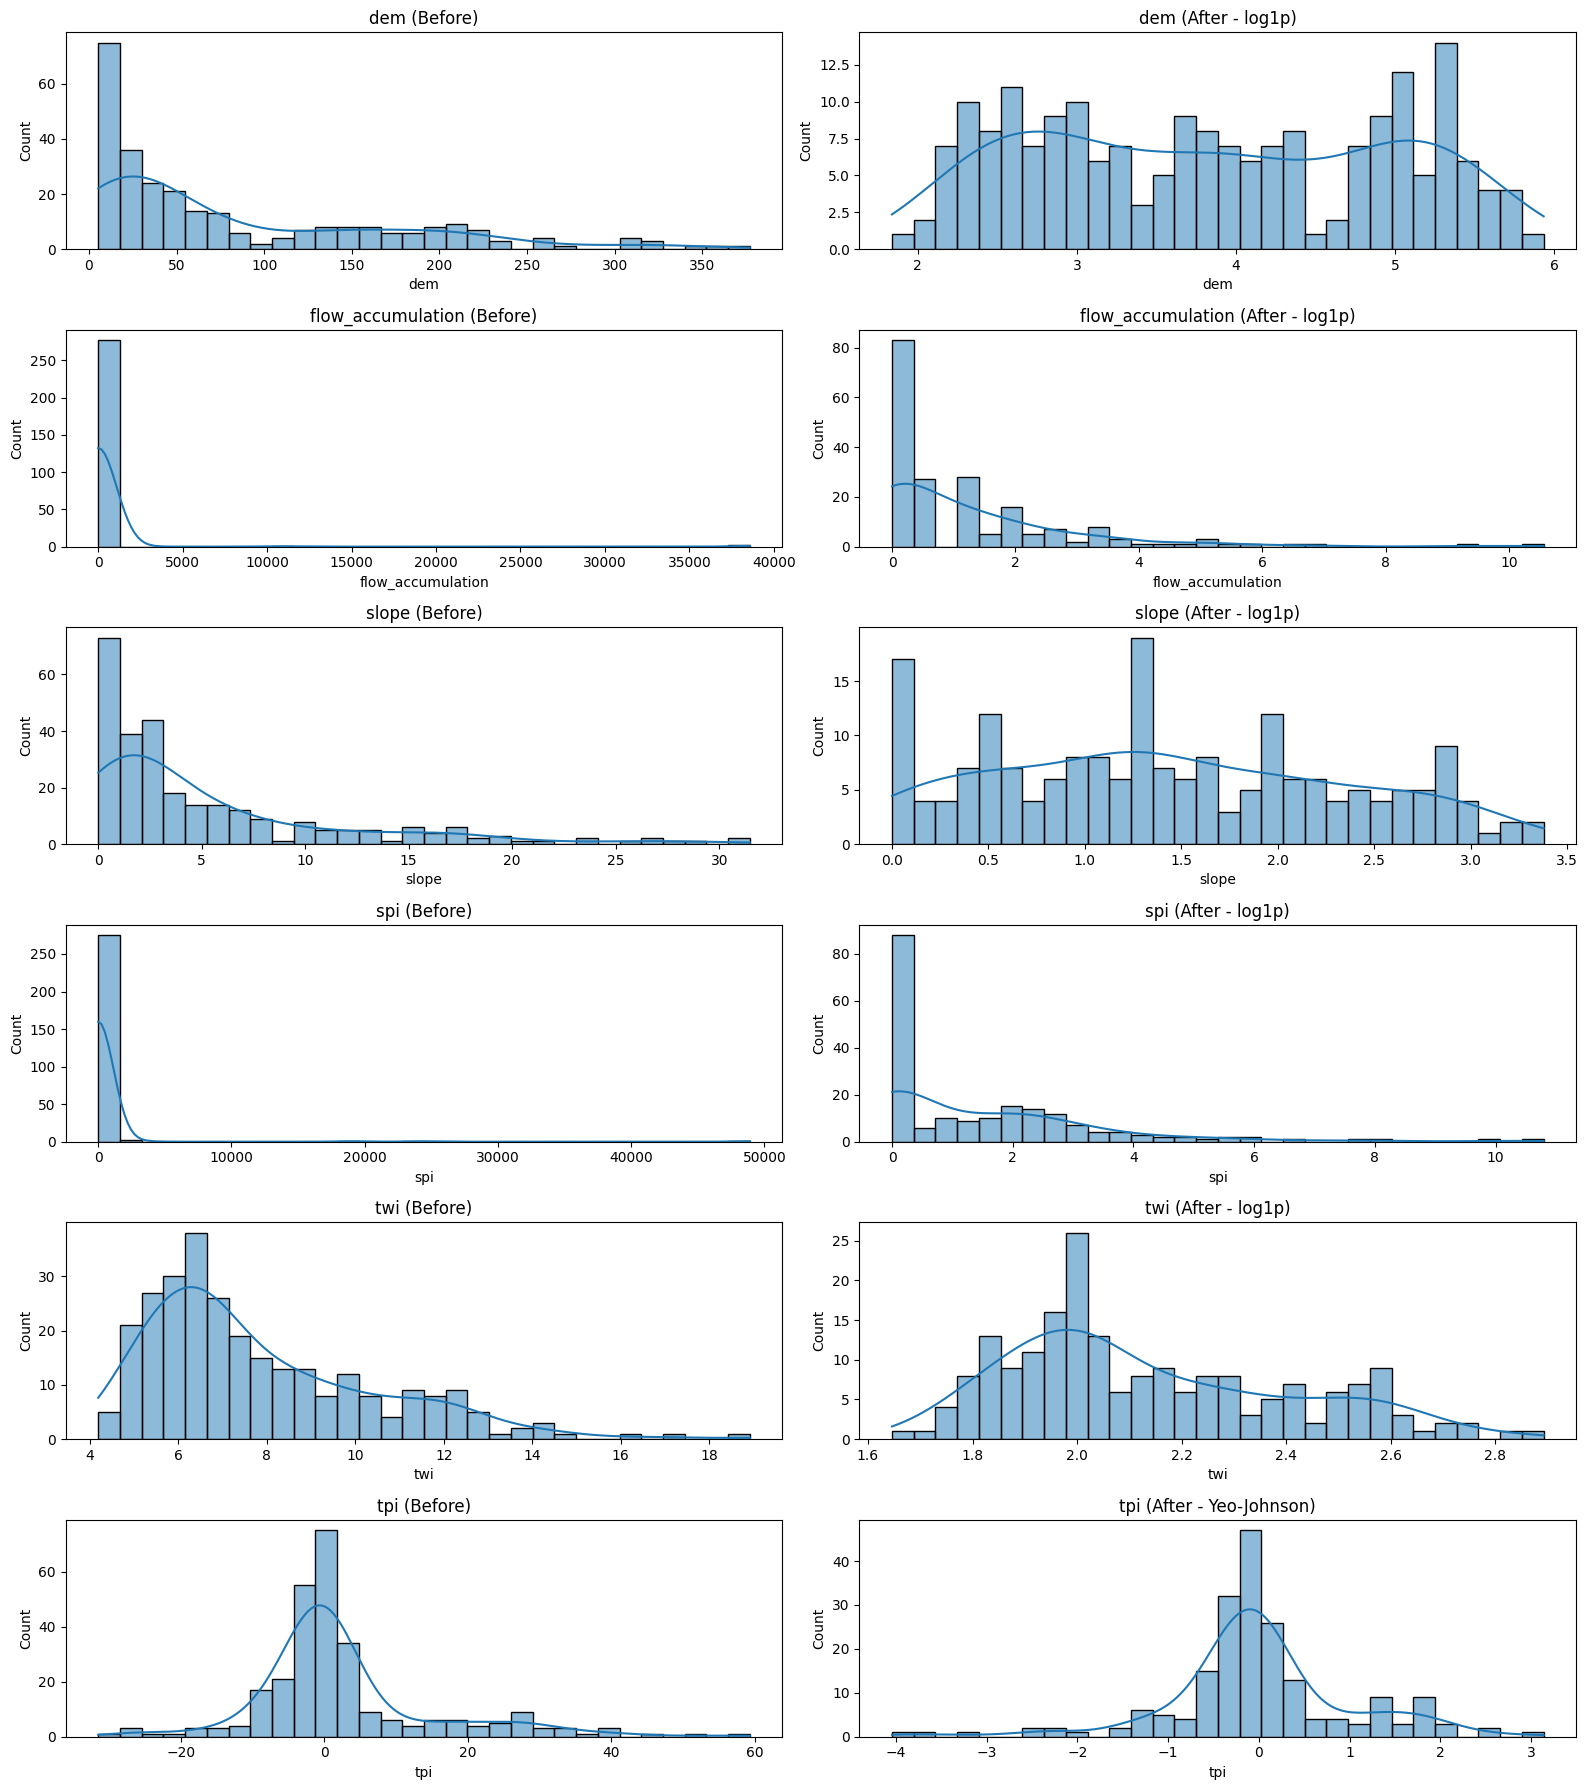

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set layout
plt.figure(figsize=(16, len(all_transformed_cols) * 3))

for i, col in enumerate(all_transformed_cols):
    # Plot BEFORE transformation
    plt.subplot(len(all_transformed_cols), 2, 2*i + 1)
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(f'{col} (Before)')

    # Plot AFTER transformation
    plt.subplot(len(all_transformed_cols), 2, 2*i + 2)
    if col in log1p_cols:
        sns.histplot(X_train[col], bins=30, kde=True)
        plt.title(f'{col} (After - log1p)')
    else:
        sns.histplot(X_train[col], bins=30, kde=True)
        plt.title(f'{col} (After - Yeo-Johnson)')

plt.tight_layout()
plt.show()

## Min-Max Normalization
Normalize all continuous features to the [0, 1] range.

In [ ]:
continuous_cols = [col for col in X_train.columns
                   if col not in categorical_cols + ['aspect_sin', 'aspect_cos']]

In [ ]:
scaler = MinMaxScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [ ]:
print(f"Scaled features: {continuous_cols}")
print(f"Kept as-is: aspect_sin, aspect_cos (already in [-1,1])")

Scaled features: ['dem', 'distance_from_river', 'flow_accumulation', 'plan_curvature', 'profile_curvature', 'rainfall', 'slope', 'spi', 'tpi', 'tri', 'twi']
Kept as-is: aspect_sin, aspect_cos (already in [-1,1])


In [ ]:
# Check shapes
print(f"\nFinal shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")


Final shapes:
  X_train: (196, 16)
  X_test: (84, 16)
  y_train: (196,)
  y_test: (84,)


In [ ]:
# Check feature ranges
print(f"\nFeature ranges (train set):")
print(f"  aspect_sin: [{X_train['aspect_sin'].min():.3f}, {X_train['aspect_sin'].max():.3f}]")
print(f"  aspect_cos: [{X_train['aspect_cos'].min():.3f}, {X_train['aspect_cos'].max():.3f}]")
for col in continuous_cols:  # Show first 3
    print(f"  {col}: [{X_train[col].min():.3f}, {X_train[col].max():.3f}]")


Feature ranges (train set):
  aspect_sin: [-0.999, 0.998]
  aspect_cos: [-0.999, 1.000]
  dem: [0.000, 1.000]
  distance_from_river: [0.000, 1.000]
  flow_accumulation: [0.000, 1.000]
  plan_curvature: [0.000, 1.000]
  profile_curvature: [0.000, 1.000]
  rainfall: [0.000, 1.000]
  slope: [0.000, 1.000]
  spi: [0.000, 1.000]
  tpi: [0.000, 1.000]
  tri: [0.000, 1.000]
  twi: [0.000, 1.000]


## SHAP


In [ ]:
!pip install catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

cat_cols = ['soil', 'lithology', 'land_use']

X_train_shap = X_train.copy()
cat_idx = [X_train_shap.columns.get_loc(c) for c in cat_cols if c in X_train_shap.columns]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_importances = []
oof_pred = np.zeros(len(X_train_shap))

# For plots: store SHAP + X on the SAME data
shap_list = []
X_list = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_shap, y_train), 1):
    X_tr = X_train_shap.iloc[tr_idx].copy()
    X_va = X_train_shap.iloc[va_idx].copy()
    y_tr = y_train.iloc[tr_idx]
    y_va = y_train.iloc[va_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_idx or None)
    valid_pool = Pool(X_va, y_va, cat_features=cat_idx or None)

    model = CatBoostClassifier(
        depth=5, learning_rate=0.08, n_estimators=2000, l2_leaf_reg=6,
        loss_function='Logloss', eval_metric='AUC',
        random_state=42, verbose=False, allow_writing_files=False
    )
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True, early_stopping_rounds=100)

    # OOF predictions (for sanity check)
    oof_pred[va_idx] = model.predict_proba(valid_pool)[:, 1]

    # SHAP computed on TRAIN fold (consistent with feature selection)
    shap_vals = model.get_feature_importance(train_pool, type='ShapValues')[:, :-1]

    # Store matching X and SHAP for plotting
    shap_list.append(shap_vals)
    X_list.append(X_tr)

    # importance for ranking
    fold_importances.append(np.abs(shap_vals).mean(axis=0))

# Aggregate ranking
mean_importance = np.mean(np.vstack(fold_importances), axis=0)
shap_rank = pd.Series(mean_importance, index=X_train_shap.columns).sort_values(ascending=False)

# Sanity check metrics
oof_auc = roc_auc_score(y_train, oof_pred)
oof_ap = average_precision_score(y_train, oof_pred)
oof_f1 = f1_score(y_train, (oof_pred >= 0.5).astype(int))
print(f"OOF AUC: {oof_auc:.3f} | OOF PR-AUC: {oof_ap:.3f} | OOF F1: {oof_f1:.3f}")

OOF AUC: 0.962 | OOF PR-AUC: 0.959 | OOF F1: 0.876


In [ ]:
# 90% cumulative selection (your version ≤ 0.90)
cum = shap_rank.cumsum() / shap_rank.sum()
selected = cum[cum <= 0.90].index.tolist()
if len(selected) < 5:
    selected = shap_rank.index[:10].tolist()

print("\nTop-10 SHAP features:\n", shap_rank.head(10))
print("\nSelected (≤90% cumulative or min 10):\n", selected)


Top-10 SHAP features:
 lithology              0.673327
land_use               0.443434
distance_from_river    0.215255
dem                    0.207238
rainfall               0.180042
slope                  0.122462
tri                    0.086572
twi                    0.073244
tpi                    0.064357
plan_curvature         0.025997
dtype: float64

Selected (≤90% cumulative or min 10):
 ['lithology', 'land_use', 'distance_from_river', 'dem', 'rainfall', 'slope', 'tri']


Beeswarm matrix shapes: (784, 16) (784, 16)


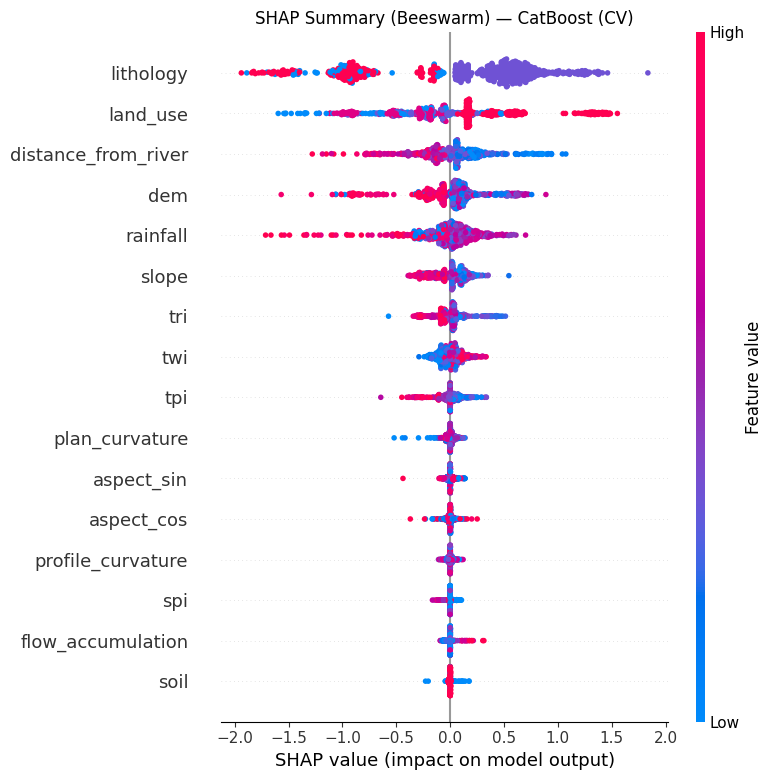

In [ ]:
# Concatenate for plotting
X_bee = pd.concat(X_list, axis=0)
shap_bee = np.vstack(shap_list)

print("Beeswarm matrix shapes:", shap_bee.shape, X_bee.shape)

plt.figure()
shap.summary_plot(shap_bee, X_bee, show=False, max_display=20)
plt.title("SHAP Summary (Beeswarm) — CatBoost (CV)")
plt.tight_layout()
plt.show()

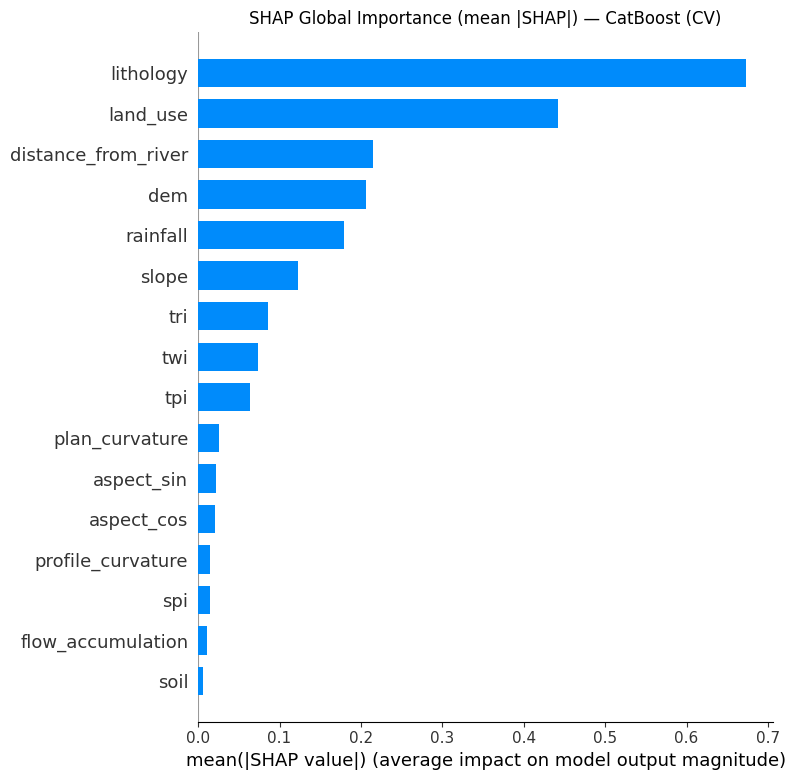

In [ ]:
plt.figure()
shap.summary_plot(shap_bee, X_bee, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Global Importance (mean |SHAP|) — CatBoost (CV)")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

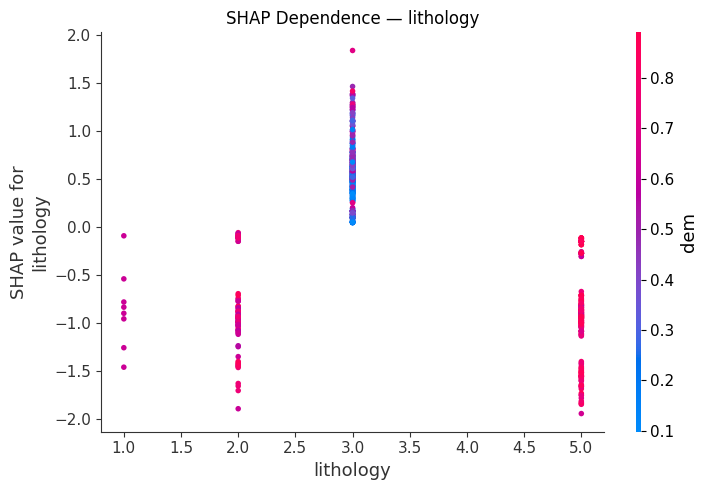

<Figure size 640x480 with 0 Axes>

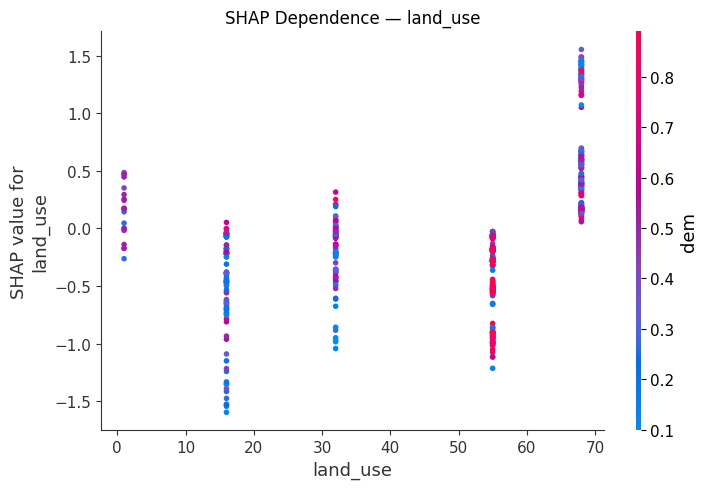

<Figure size 640x480 with 0 Axes>

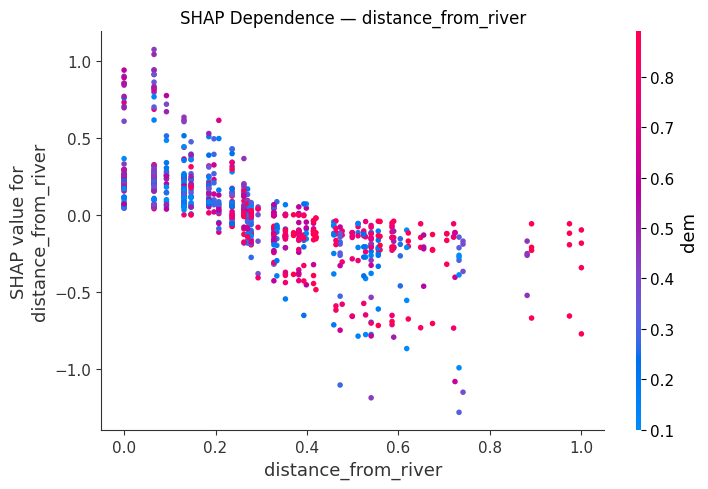

<Figure size 640x480 with 0 Axes>

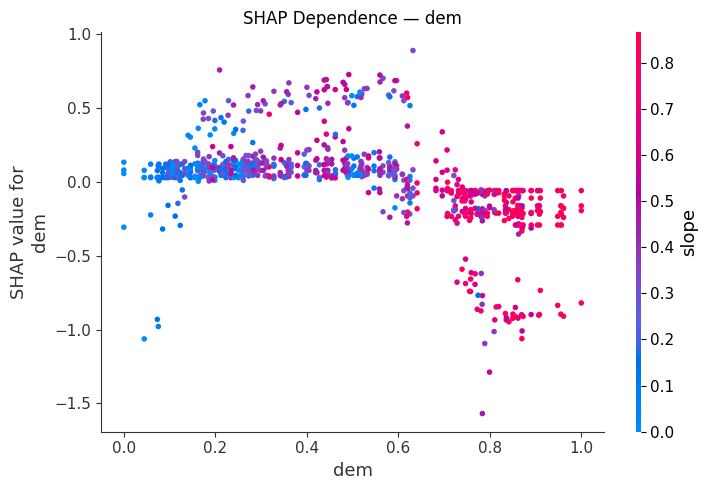

In [ ]:
top_feats = selected[:4]  # or pick manually
for f in top_feats:
    plt.figure()
    shap.dependence_plot(f, shap_bee, X_bee, show=False, interaction_index="auto")
    plt.title(f"SHAP Dependence — {f}")
    plt.tight_layout()
    plt.show()

In [ ]:
# After feature selection
print(f"\n{'='*80}")
print("FEATURE SELECTION SUMMARY")
print(f"{'='*80}")
print(f"Original features: {len(X_train.columns)}")
print(f"Selected features: {len(selected)}")
print(f"Reduction: {(1 - len(selected)/len(X_train.columns))*100:.1f}%")
print(f"Cumulative SHAP captured: {(shap_rank[selected].sum() / shap_rank.sum())*100:.1f}%")

# Show what was dropped
dropped = [col for col in X_train.columns if col not in selected]
print(f"\nDropped features ({len(dropped)}):")
for col in dropped:
    print(f"  • {col}: {shap_rank[col]:.6f} (rank {list(shap_rank.index).index(col)+1}/{len(shap_rank)})")


FEATURE SELECTION SUMMARY
Original features: 16
Selected features: 7
Reduction: 56.2%
Cumulative SHAP captured: 88.4%

Dropped features (9):
  • flow_accumulation: 0.011109 (rank 15/16)
  • plan_curvature: 0.025997 (rank 10/16)
  • profile_curvature: 0.014992 (rank 13/16)
  • soil: 0.006109 (rank 16/16)
  • spi: 0.014575 (rank 14/16)
  • tpi: 0.064357 (rank 9/16)
  • twi: 0.073244 (rank 8/16)
  • aspect_sin: 0.021689 (rank 11/16)
  • aspect_cos: 0.020689 (rank 12/16)


In [ ]:
selected

['lithology',
 'land_use',
 'distance_from_river',
 'dem',
 'rainfall',
 'slope',
 'tri']

# Modeling


## CatBoost

In [ ]:
!pip install tensorflow

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CATBOOST MODEL
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import os
import json
import pickle
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score)
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt


def eval_catboost_robust(features, Xtr, ytr, Xte, yte, cat_cols_all, name, n_cv_folds=5, plot_loss=True):
    """Evaluate CatBoost with loss plotting."""
    print(f"\n{'='*80}")
    print(f"CatBoost: {name}")
    print(f"{'='*80}")
    print(f"Features: {len(features)}")

    cat_cols = [c for c in cat_cols_all if c in features]

    # ════════════════════════════════════════════════════════════════
    # 1. Cross-Validation
    # ════════════════════════════════════════════════════════════════
    print(f"\n[1/2] Running {n_cv_folds}-fold CV...")

    skf = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=42)
    cv_metrics = {'AUC': [], 'F1': [], 'Recall': [], 'Precision': []}
    oof_proba = np.zeros(len(ytr))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(Xtr[features], ytr), 1):
        X_tr, X_val = Xtr[features].iloc[tr_idx], Xtr[features].iloc[val_idx]
        y_tr, y_val = ytr.iloc[tr_idx], ytr.iloc[val_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
        val_pool = Pool(X_val, y_val, cat_features=cat_cols)

        cb_model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.03,
            depth=5,  # Middle ground between 3 and 6
            l2_leaf_reg=5,  # Moderate regularization
            random_seed=42,
            verbose=0,
            eval_metric='AUC',
            early_stopping_rounds=50,
            subsample=0.8,
            colsample_bylevel=0.8
        )

        cb_model.fit(train_pool, eval_set=val_pool, verbose=0)

        val_proba = cb_model.predict_proba(X_val)[:, 1]
        oof_proba[val_idx] = val_proba

        val_pred = (val_proba >= 0.5).astype(int)
        cv_metrics['AUC'].append(roc_auc_score(y_val, val_proba))
        cv_metrics['F1'].append(f1_score(y_val, val_pred))
        cv_metrics['Recall'].append(recall_score(y_val, val_pred))
        cv_metrics['Precision'].append(precision_score(y_val, val_pred))
        print(f"  Fold {fold}: AUC={cv_metrics['AUC'][-1]:.4f}, F1={cv_metrics['F1'][-1]:.4f}, "
              f"Recall={cv_metrics['Recall'][-1]:.4f}, Precision={cv_metrics['Precision'][-1]:.4f}")

    oof_auc = roc_auc_score(ytr, oof_proba)
    oof_pred = (oof_proba >= 0.5).astype(int)
    oof_f1 = f1_score(ytr, oof_pred)
    oof_recall = recall_score(ytr, oof_pred)
    oof_precision = precision_score(ytr, oof_pred)

    print(f"\n  CV Summary:")
    print(f"    AUC:       {np.mean(cv_metrics['AUC']):.4f} ± {np.std(cv_metrics['AUC']):.4f}")
    print(f"    F1:        {np.mean(cv_metrics['F1']):.4f} ± {np.std(cv_metrics['F1']):.4f}")
    print(f"    Recall:    {np.mean(cv_metrics['Recall']):.4f} ± {np.std(cv_metrics['Recall']):.4f}")
    print(f"    Precision: {np.mean(cv_metrics['Precision']):.4f} ± {np.std(cv_metrics['Precision']):.4f}")
    print(f"  OOF: AUC={oof_auc:.4f}, F1={oof_f1:.4f}, Recall={oof_recall:.4f}, Precision={oof_precision:.4f}")

    # ════════════════════════════════════════════════════════════════
    # 2. Final Model
    # ════════════════════════════════════════════════════════════════
    print(f"\n[2/2] Training final model...")

    X_tr, X_val, y_tr, y_val = train_test_split(
        Xtr[features], ytr, test_size=0.2, stratify=ytr, random_state=42
    )

    train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)

    cb_model_final = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=5,  # Middle ground
        l2_leaf_reg=5,  # Moderate regularization
        random_seed=42,
        verbose=0,
        eval_metric='AUC',
        loss_function='Logloss',
        early_stopping_rounds=50,
        subsample=0.8,
        colsample_bylevel=0.8
    )

    cb_model_final.fit(train_pool, eval_set=val_pool, verbose=0)

    # Get final model history - extract LOSS (not AUC)
    eval_results = cb_model_final.evals_result_
    final_history = {
        'train_loss': eval_results['learn']['Logloss'],
        'val_loss': eval_results['validation']['Logloss']
    }

    test_proba = cb_model_final.predict_proba(Xte[features])[:, 1]
    test_pred = (test_proba >= 0.5).astype(int)

    print(f"  Test → AUC: {roc_auc_score(yte, test_proba):.4f}, "
          f"F1: {f1_score(yte, test_pred):.4f}, "
          f"Recall: {recall_score(yte, test_pred):.4f}, "
          f"Precision: {precision_score(yte, test_pred):.4f}")

    # Plot final model loss curve
    if plot_loss:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        fig.suptitle(f'Final Model Training History - {name}', fontsize=14, fontweight='bold')

        ax.plot(final_history['train_loss'], label='Train Loss', linewidth=2)
        ax.plot(final_history['val_loss'], label='Val Loss', linewidth=2)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Logloss')
        ax.set_title('Loss Curve')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print diagnosis
        final_train_loss = final_history['train_loss'][-1]
        final_val_loss = final_history['val_loss'][-1]

        print(f"\n  Training Diagnosis:")
        print(f"    Final Train Loss: {final_train_loss:.4f} | Val Loss: {final_val_loss:.4f}")
        print(f"    Gap: {final_val_loss - final_train_loss:.4f}")

        if final_val_loss > final_train_loss * 1.3:
            print(f"  Potential overfitting detected (val loss >> train loss)")
        elif final_val_loss < final_train_loss * 0.9:
            print(f"  Unusual: val loss lower than train loss")
        else:
            print(f"    ✓  Good fit (train and val losses are close)")

    # ════════════════════════════════════════════════════════════════
    # 3. Save Model
    # ════════════════════════════════════════════════════════════════
    os.makedirs('saved_models', exist_ok=True)

    # Create safe filename from name
    safe_name = name.lower().replace(' ', '_')

    try:
        # Save CatBoost model in native format
        model_path = f'saved_models/catboost_{safe_name}.cbm'
        cb_model_final.save_model(model_path)
        print(f"\n  ✓ Model saved to {os.path.abspath(model_path)}")

        # Save metadata as JSON (more portable than pickle)
        metadata_path = f'saved_models/catboost_{safe_name}_metadata.json'
        metadata = {
            'features': features,
            'cat_cols': cat_cols,
            'model_params': cb_model_final.get_params()
        }
        with open(metadata_path, 'w') as file:
            json.dump(metadata, file, indent=2)
        print(f"  ✓ Metadata saved to {os.path.abspath(metadata_path)}")

    except Exception as e:
        print(f"\n  ✗ Error saving model: {e}")

    return {
        "Model": "CatBoost",
        "Setting": name,
        "n_features": len(features),
        "CV_AUC": f"{np.mean(cv_metrics['AUC']):.4f}±{np.std(cv_metrics['AUC']):.4f}",
        "CV_F1": f"{np.mean(cv_metrics['F1']):.4f}±{np.std(cv_metrics['F1']):.4f}",
        "CV_Recall": f"{np.mean(cv_metrics['Recall']):.4f}±{np.std(cv_metrics['Recall']):.4f}",
        "CV_Precision": f"{np.mean(cv_metrics['Precision']):.4f}±{np.std(cv_metrics['Precision']):.4f}",
        "OOF_AUC": round(oof_auc, 4),
        "OOF_F1": round(oof_f1, 4),
        "OOF_Recall": round(oof_recall, 4),
        "OOF_Precision": round(oof_precision, 4),
        "Test_AUC": round(roc_auc_score(yte, test_proba), 4),
        "Test_F1": round(f1_score(yte, test_pred), 4),
        "Test_Recall": round(recall_score(yte, test_pred), 4),
        "Test_Precision": round(precision_score(yte, test_pred), 4),
        "Test_Accuracy": round(accuracy_score(yte, test_pred), 4),
    }

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 4. RUN COMPARISON
# ════════════════════════════════════════════════════════════════════════════

cat_cols = ['soil', 'lithology', 'land_use']
all_features = list(X_train.columns)
selected_features = selected


CatBoost: All Features
Features: 16

[1/2] Running 5-fold CV...
  Fold 1: AUC=1.0000, F1=0.9744, Recall=0.9500, Precision=1.0000
  Fold 2: AUC=0.8987, F1=0.8261, Recall=1.0000, Precision=0.7037
  Fold 3: AUC=0.9895, F1=0.9000, Recall=0.9474, Precision=0.8571
  Fold 4: AUC=1.0000, F1=0.9268, Recall=1.0000, Precision=0.8636
  Fold 5: AUC=0.9132, F1=0.8182, Recall=0.9000, Precision=0.7500

  CV Summary:
    AUC:       0.9603 ± 0.0448
    F1:        0.8891 ± 0.0597
    Recall:    0.9595 ± 0.0376
    Precision: 0.8349 ± 0.1030
  OOF: AUC=0.9489, F1=0.8857, Recall=0.9588, Precision=0.8230

[2/2] Training final model...
  Test → AUC: 0.8639, F1: 0.7692, Recall: 0.7143, Precision: 0.8333


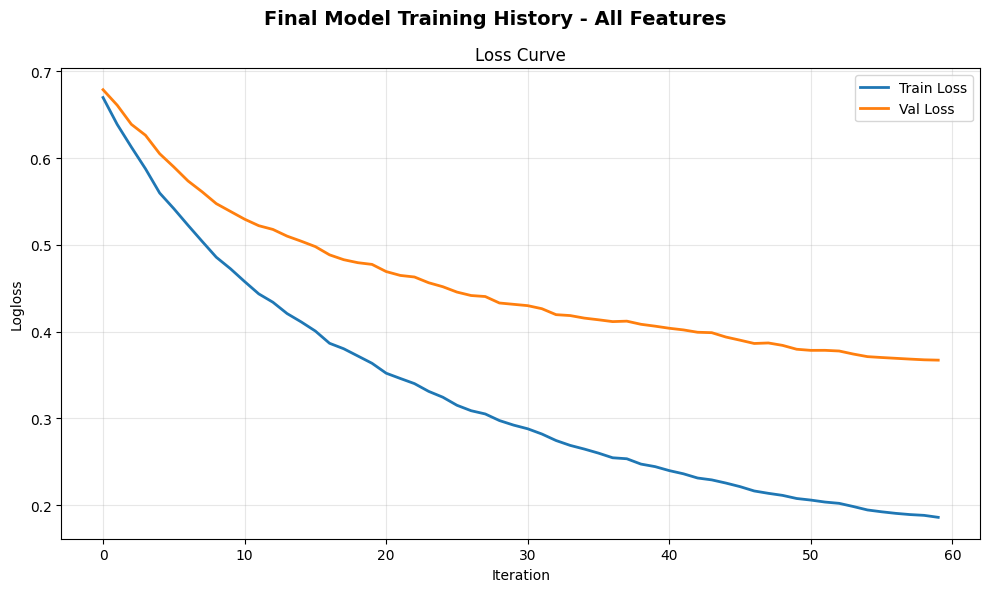


  Training Diagnosis:
    Final Train Loss: 0.1861 | Val Loss: 0.3672
    Gap: 0.1811
    ⚠️  Potential overfitting detected (val loss >> train loss)

  ✓ Model saved to /content/saved_models/catboost_all_features.cbm
  ✓ Metadata saved to /content/saved_models/catboost_all_features_metadata.json

CatBoost: SHAP Selected
Features: 7

[1/2] Running 5-fold CV...
  Fold 1: AUC=1.0000, F1=0.9524, Recall=1.0000, Precision=0.9091
  Fold 2: AUC=0.9474, F1=0.7826, Recall=0.9474, Precision=0.6667
  Fold 3: AUC=0.9895, F1=0.9000, Recall=0.9474, Precision=0.8571
  Fold 4: AUC=0.9868, F1=0.9048, Recall=1.0000, Precision=0.8261
  Fold 5: AUC=0.9316, F1=0.8718, Recall=0.8500, Precision=0.8947

  CV Summary:
    AUC:       0.9711 ± 0.0266
    F1:        0.8823 ± 0.0562
    Recall:    0.9489 ± 0.0548
    Precision: 0.8307 ± 0.0870
  OOF: AUC=0.9331, F1=0.8804, Recall=0.9485, Precision=0.8214

[2/2] Training final model...
  Test → AUC: 0.9297, F1: 0.8421, Recall: 0.7619, Precision: 0.9412


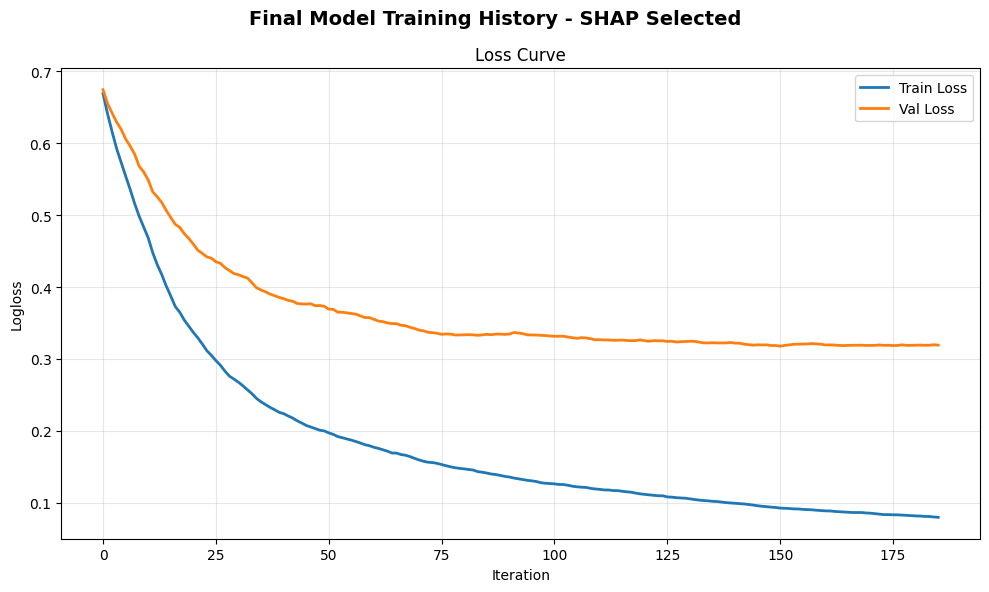


  Training Diagnosis:
    Final Train Loss: 0.0797 | Val Loss: 0.3193
    Gap: 0.2396
    ⚠️  Potential overfitting detected (val loss >> train loss)

  ✓ Model saved to /content/saved_models/catboost_shap_selected.cbm
  ✓ Metadata saved to /content/saved_models/catboost_shap_selected_metadata.json

FINAL COMPARISON
   Model       Setting  n_features        CV_AUC         CV_F1     CV_Recall  CV_Precision  OOF_AUC  OOF_F1  OOF_Recall  OOF_Precision  Test_AUC  Test_F1  Test_Recall  Test_Precision  Test_Accuracy
CatBoost  All Features          16 0.9603±0.0448 0.8891±0.0597 0.9595±0.0376 0.8349±0.1030   0.9489  0.8857      0.9588         0.8230    0.8639   0.7692       0.7143          0.8333         0.7857
CatBoost SHAP Selected           7 0.9711±0.0266 0.8823±0.0562 0.9489±0.0548 0.8307±0.0870   0.9331  0.8804      0.9485         0.8214    0.9297   0.8421       0.7619          0.9412         0.8571


In [ ]:
# Initialize results list
results = []

# Run both models with plotting
for features, label in [(all_features, "All Features"), (selected_features, "SHAP Selected")]:
    results.append(eval_catboost_robust(features, X_train, y_train, X_test, y_test, cat_cols, label))

# Compare results
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("FINAL COMPARISON")
print("="*80)
print(df_results.to_string(index=False))

## MLP

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 2. MLP MODEL (with consistent encoding and proper saving)
# ════════════════════════════════════════════════════════════════════════════

# Required imports (add these at the top of your notebook if not already present)
import numpy as np
import pandas as pd
import os
import json
import pickle
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score)
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


def build_mlp_model(num_cols, cat_cols, cat_cardinality, emb_dim=16):
    """Build MLP model with embeddings."""
    inputs = []
    embeddings = []

    if num_cols:
        inp_num = Input(shape=(len(num_cols),), name='numeric_input')
        inputs.append(inp_num)
        embeddings.append(inp_num)

    for c in cat_cols:
        inp = Input(shape=(1,), dtype='int32', name=f'{c}_input')
        emb = layers.Embedding(
            input_dim=max(2, cat_cardinality[c]),
            output_dim=emb_dim,
            embeddings_regularizer=tf.keras.regularizers.l2(0.01)
        )(inp)
        emb = layers.Flatten()(emb)
        inputs.append(inp)
        embeddings.append(emb)

    x = layers.Concatenate()(embeddings)
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(0.1)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    mlp_model = Model(inputs=inputs, outputs=out)
    mlp_model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return mlp_model


def make_feed(Xnum, Xcat, cat_cols):
    """Create input feed list."""
    feed = []
    if Xnum is not None:
        feed.append(Xnum)
    for c in cat_cols:
        feed.append(Xcat[c].reshape(-1, 1))
    return feed


def prepare_data_for_keras(features, X_train_full, X_test_full, y_train_full, cat_cols_all,
                           label_encoders=None, cat_cardinality=None):
    """Prepare data for Keras models with consistent encoding."""
    cat_cols = [c for c in cat_cols_all if c in features]
    num_cols = [c for c in features if c not in cat_cols]

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full[features], y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
    )

    Xtr, Xval, Xte = X_tr.copy(), X_val.copy(), X_test_full[features].copy()

    # Use provided encoders instead of fitting new ones
    if label_encoders is None:
        # Only fit if not provided (for backwards compatibility)
        label_encoders = {}
        cat_cardinality = {}
        for col in cat_cols:
            le = LabelEncoder()
            col_data = Xtr[col].astype(str).fillna("Unknown")
            le.fit(pd.concat([col_data, pd.Series(["Unknown"])]))
            label_encoders[col] = le
            cat_cardinality[col] = len(le.classes_)

    # Transform using the encoders
    for col in cat_cols:
        le = label_encoders[col]

        Xtr[col] = Xtr[col].astype(str).fillna("Unknown")
        Xtr[col] = Xtr[col].where(Xtr[col].isin(le.classes_), "Unknown")
        Xtr[col] = le.transform(Xtr[col])

        Xval[col] = Xval[col].astype(str).fillna("Unknown")
        Xval[col] = Xval[col].where(Xval[col].isin(le.classes_), "Unknown")
        Xval[col] = le.transform(Xval[col])

        Xte[col] = Xte[col].astype(str).fillna("Unknown")
        Xte[col] = Xte[col].where(Xte[col].isin(le.classes_), "Unknown")
        Xte[col] = le.transform(Xte[col])

    Xtr_num = Xtr[num_cols].astype('float32').values if num_cols else None
    Xval_num = Xval[num_cols].astype('float32').values if num_cols else None
    Xte_num = Xte[num_cols].astype('float32').values if num_cols else None

    Xtr_cat = {c: Xtr[c].astype('int32').values for c in cat_cols}
    Xval_cat = {c: Xval[c].astype('int32').values for c in cat_cols}
    Xte_cat = {c: Xte[c].astype('int32').values for c in cat_cols}

    return {
        'train_feed': make_feed(Xtr_num, Xtr_cat, cat_cols),
        'val_feed': make_feed(Xval_num, Xval_cat, cat_cols),
        'test_feed': make_feed(Xte_num, Xte_cat, cat_cols),
        'y_tr': y_tr, 'y_val': y_val,
        'num_cols': num_cols, 'cat_cols': cat_cols, 'cat_cardinality': cat_cardinality,
        'label_encoders': label_encoders
    }


def eval_mlp_robust(features, Xtr, ytr, Xte, yte, cat_cols_all, name, n_cv_folds=5, plot_loss=True):
    """Evaluate MLP with consistent encoding across all folds."""
    print(f"\n{'='*80}")
    print(f"MLP: {name}")
    print(f"{'='*80}")
    print(f"Features: {len(features)}")

    cat_cols = [c for c in cat_cols_all if c in features]
    num_cols = [c for c in features if c not in cat_cols]

    # ════════════════════════════════════════════════════════════════
    # 0. Fit Label Encoders ONCE on Full Training Data
    # ════════════════════════════════════════════════════════════════
    print(f"\n[0/2] Fitting label encoders on full training data...")
    global_encoders = {}
    global_cardinality = {}

    for col in cat_cols:
        le = LabelEncoder()
        col_data = Xtr[col].astype(str).fillna("Unknown")
        le.fit(pd.concat([col_data, pd.Series(["Unknown"])]))
        global_encoders[col] = le
        global_cardinality[col] = len(le.classes_)
        print(f"  {col}: {global_cardinality[col]} unique categories")

    # ════════════════════════════════════════════════════════════════
    # 1. Cross-Validation with Consistent Encoders
    # ════════════════════════════════════════════════════════════════
    print(f"\n[1/2] Running {n_cv_folds}-fold CV with consistent encoders...")

    skf = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=42)
    cv_metrics = {'AUC': [], 'F1': [], 'Recall': [], 'Precision': []}
    oof_proba = np.zeros(len(ytr))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(Xtr[features], ytr), 1):
        X_tr, X_val = Xtr[features].iloc[tr_idx].copy(), Xtr[features].iloc[val_idx].copy()
        y_tr, y_val = ytr.iloc[tr_idx], ytr.iloc[val_idx]

        # Transform using GLOBAL encoders (not fitting new ones)
        for col in cat_cols:
            le = global_encoders[col]

            X_tr[col] = X_tr[col].astype(str).fillna("Unknown")
            X_tr[col] = X_tr[col].where(X_tr[col].isin(le.classes_), "Unknown")
            X_tr[col] = le.transform(X_tr[col])

            X_val[col] = X_val[col].astype(str).fillna("Unknown")
            X_val[col] = X_val[col].where(X_val[col].isin(le.classes_), "Unknown")
            X_val[col] = le.transform(X_val[col])

        Xtr_num = X_tr[num_cols].astype('float32').values if num_cols else None
        Xval_num = X_val[num_cols].astype('float32').values if num_cols else None
        train_feed = make_feed(Xtr_num, {c: X_tr[c].astype('int32').values for c in cat_cols}, cat_cols)
        val_feed = make_feed(Xval_num, {c: X_val[c].astype('int32').values for c in cat_cols}, cat_cols)

        # Build model with GLOBAL cardinality (ensures consistent architecture)
        mlp_model = build_mlp_model(num_cols, cat_cols, global_cardinality)
        mlp_model.fit(train_feed, y_tr.values, validation_data=(val_feed, y_val.values),
                  epochs=500, batch_size=128,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)],
                  verbose=0)

        val_proba = mlp_model.predict(val_feed, verbose=0).ravel()
        oof_proba[val_idx] = val_proba

        val_pred = (val_proba >= 0.5).astype(int)
        cv_metrics['AUC'].append(roc_auc_score(y_val, val_proba))
        cv_metrics['F1'].append(f1_score(y_val, val_pred))
        cv_metrics['Recall'].append(recall_score(y_val, val_pred))
        cv_metrics['Precision'].append(precision_score(y_val, val_pred))
        print(f"  Fold {fold}: AUC={cv_metrics['AUC'][-1]:.4f}, F1={cv_metrics['F1'][-1]:.4f}, "
              f"Recall={cv_metrics['Recall'][-1]:.4f}, Precision={cv_metrics['Precision'][-1]:.4f}")

    oof_auc = roc_auc_score(ytr, oof_proba)
    oof_pred = (oof_proba >= 0.5).astype(int)
    oof_f1 = f1_score(ytr, oof_pred)
    oof_recall = recall_score(ytr, oof_pred)
    oof_precision = precision_score(ytr, oof_pred)

    print(f"\n  CV Summary:")
    print(f"    AUC:       {np.mean(cv_metrics['AUC']):.4f} ± {np.std(cv_metrics['AUC']):.4f}")
    print(f"    F1:        {np.mean(cv_metrics['F1']):.4f} ± {np.std(cv_metrics['F1']):.4f}")
    print(f"    Recall:    {np.mean(cv_metrics['Recall']):.4f} ± {np.std(cv_metrics['Recall']):.4f}")
    print(f"    Precision: {np.mean(cv_metrics['Precision']):.4f} ± {np.std(cv_metrics['Precision']):.4f}")
    print(f"  OOF: AUC={oof_auc:.4f}, F1={oof_f1:.4f}, Recall={oof_recall:.4f}, Precision={oof_precision:.4f}")

    # ════════════════════════════════════════════════════════════════
    # 2. Final Model with Same Encoders
    # ════════════════════════════════════════════════════════════════
    print(f"\n[2/2] Training final model with consistent encoders...")

    data = prepare_data_for_keras(features, Xtr, Xte, ytr, cat_cols_all,
                                   label_encoders=global_encoders,
                                   cat_cardinality=global_cardinality)

    mlp_model_final = build_mlp_model(data['num_cols'], data['cat_cols'], data['cat_cardinality'])
    final_history = mlp_model_final.fit(data['train_feed'], data['y_tr'].values,
              validation_data=(data['val_feed'], data['y_val'].values),
              epochs=500, batch_size=128,
              callbacks=[EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
                        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)],
              verbose=0)

    test_proba = mlp_model_final.predict(data['test_feed'], verbose=0).ravel()
    test_pred = (test_proba >= 0.5).astype(int)

    print(f"  Test → AUC: {roc_auc_score(yte, test_proba):.4f}, "
          f"F1: {f1_score(yte, test_pred):.4f}, "
          f"Recall: {recall_score(yte, test_pred):.4f}, "
          f"Precision: {precision_score(yte, test_pred):.4f}")

    # Plot final model loss curve
    if plot_loss:
        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'Final Model Training History - {name}', fontsize=14, fontweight='bold')

        axes[0].plot(final_history.history['loss'], label='Train Loss', linewidth=2)
        axes[0].plot(final_history.history['val_loss'], label='Val Loss', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(final_history.history['auc'], label='Train AUC', linewidth=2)
        axes[1].plot(final_history.history['val_auc'], label='Val AUC', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('AUC')
        axes[1].set_title('AUC Curve')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


    # ════════════════════════════════════════════════════════════════
    # 3. Save Model (Properly)
    # ════════════════════════════════════════════════════════════════
    os.makedirs('saved_models', exist_ok=True)

    # Create safe filename from name
    safe_name = name.lower().replace(' ', '_')

    try:
        # Save Keras model in native format (.keras is recommended over .h5)
        model_path = f'saved_models/mlp_{safe_name}.keras'
        mlp_model_final.save(model_path)
        print(f"\n  ✓ Model saved to {os.path.abspath(model_path)}")

        # Save metadata as JSON (more portable than pickle)
        metadata_path = f'saved_models/mlp_{safe_name}_metadata.json'
        metadata = {
            'features': features,
            'cat_cols': data['cat_cols'],
            'num_cols': data['num_cols'],
            'cat_cardinality': data['cat_cardinality'],
            'label_encoders': {col: le.classes_.tolist() for col, le in data['label_encoders'].items()}
        }
        with open(metadata_path, 'w') as file:
            json.dump(metadata, file, indent=2)
        print(f"  ✓ Metadata saved to {os.path.abspath(metadata_path)}")

    except Exception as e:
        print(f"\n  ✗ Error saving model: {e}")

    return {
        "Model": "MLP",
        "Setting": name,
        "n_features": len(features),
        "CV_AUC": f"{np.mean(cv_metrics['AUC']):.4f}±{np.std(cv_metrics['AUC']):.4f}",
        "CV_F1": f"{np.mean(cv_metrics['F1']):.4f}±{np.std(cv_metrics['F1']):.4f}",
        "CV_Recall": f"{np.mean(cv_metrics['Recall']):.4f}±{np.std(cv_metrics['Recall']):.4f}",
        "CV_Precision": f"{np.mean(cv_metrics['Precision']):.4f}±{np.std(cv_metrics['Precision']):.4f}",
        "OOF_AUC": round(oof_auc, 4),
        "OOF_F1": round(oof_f1, 4),
        "OOF_Recall": round(oof_recall, 4),
        "OOF_Precision": round(oof_precision, 4),
        "Test_AUC": round(roc_auc_score(yte, test_proba), 4),
        "Test_F1": round(f1_score(yte, test_pred), 4),
        "Test_Recall": round(recall_score(yte, test_pred), 4),
        "Test_Precision": round(precision_score(yte, test_pred), 4),
        "Test_Accuracy": round(accuracy_score(yte, test_pred), 4),
    }


MLP: All Features
Features: 16

[0/2] Fitting label encoders on full training data...
  soil: 3 unique categories
  lithology: 5 unique categories
  land_use: 6 unique categories

[1/2] Running 5-fold CV with consistent encoders...
  Fold 1: AUC=0.9925, F1=0.9268, Recall=0.9500, Precision=0.9048
  Fold 2: AUC=0.9105, F1=0.7826, Recall=0.9474, Precision=0.6667


  Fold 3: AUC=0.9947, F1=0.9231, Recall=0.9474, Precision=0.9000
  Fold 4: AUC=1.0000, F1=0.9500, Recall=1.0000, Precision=0.9048
  Fold 5: AUC=0.9105, F1=0.7805, Recall=0.8000, Precision=0.7619

  CV Summary:
    AUC:       0.9617 ± 0.0418
    F1:        0.8726 ± 0.0749
    Recall:    0.9289 ± 0.0675
    Precision: 0.8276 ± 0.0973
  OOF: AUC=0.9616, F1=0.8696, Recall=0.9278, Precision=0.8182

[2/2] Training final model with consistent encoders...
  Test → AUC: 0.9303, F1: 0.8333, Recall: 0.8333, Precision: 0.8333


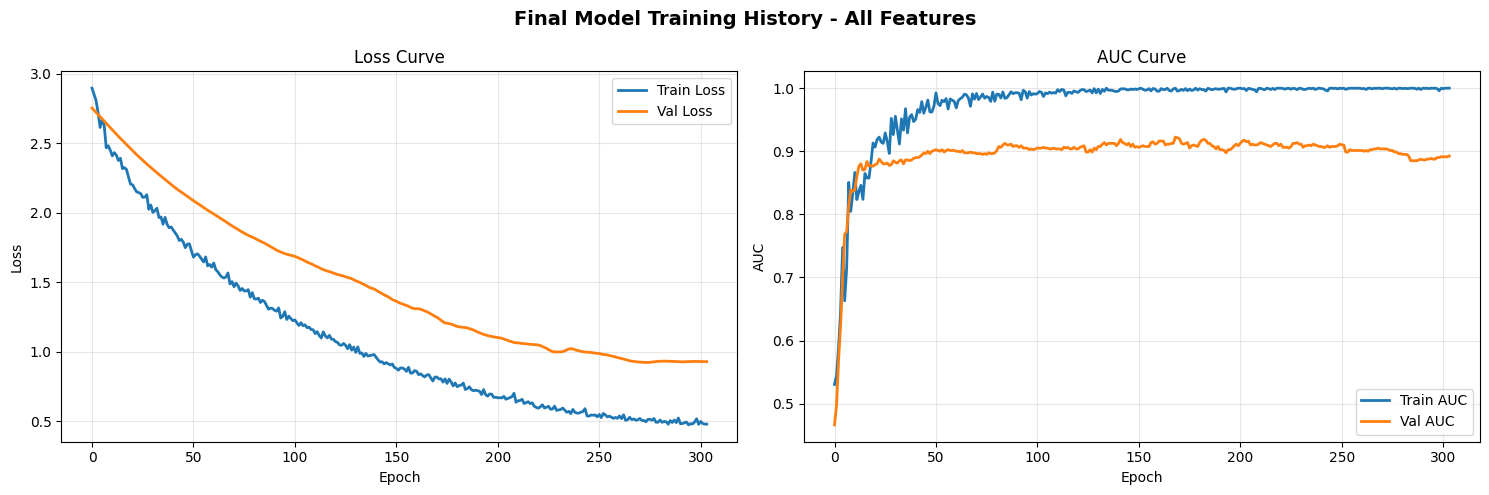


  ✓ Model saved to /content/saved_models/mlp_all_features.keras
  ✓ Metadata saved to /content/saved_models/mlp_all_features_metadata.json

MLP: SHAP Selected
Features: 7

[0/2] Fitting label encoders on full training data...
  lithology: 5 unique categories
  land_use: 6 unique categories

[1/2] Running 5-fold CV with consistent encoders...
  Fold 1: AUC=0.9800, F1=0.9000, Recall=0.9000, Precision=0.9000
  Fold 2: AUC=0.9500, F1=0.8372, Recall=0.9474, Precision=0.7500
  Fold 3: AUC=0.9500, F1=0.9231, Recall=0.9474, Precision=0.9000
  Fold 4: AUC=0.9816, F1=0.8718, Recall=0.8947, Precision=0.8500
  Fold 5: AUC=0.9395, F1=0.8500, Recall=0.8500, Precision=0.8500

  CV Summary:
    AUC:       0.9602 ± 0.0172
    F1:        0.8764 ± 0.0316
    Recall:    0.9079 ± 0.0366
    Precision: 0.8500 ± 0.0548
  OOF: AUC=0.9597, F1=0.8756, Recall=0.9072, Precision=0.8462

[2/2] Training final model with consistent encoders...
  Test → AUC: 0.9371, F1: 0.8642, Recall: 0.8333, Precision: 0.8974


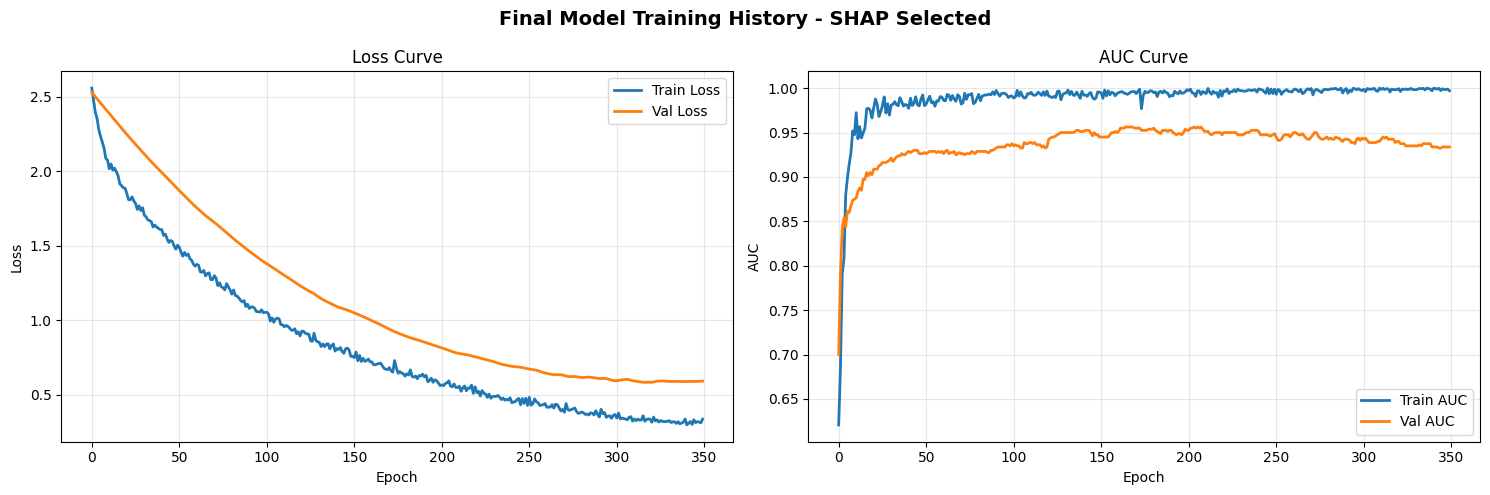


  ✓ Model saved to /content/saved_models/mlp_shap_selected.keras
  ✓ Metadata saved to /content/saved_models/mlp_shap_selected_metadata.json

FINAL COMPARISON
   Model       Setting  n_features        CV_AUC         CV_F1     CV_Recall  CV_Precision  OOF_AUC  OOF_F1  OOF_Recall  OOF_Precision  Test_AUC  Test_F1  Test_Recall  Test_Precision  Test_Accuracy
CatBoost  All Features          16 0.9603±0.0448 0.8891±0.0597 0.9595±0.0376 0.8349±0.1030   0.9489  0.8857      0.9588         0.8230    0.8639   0.7692       0.7143          0.8333         0.7857
CatBoost SHAP Selected           7 0.9711±0.0266 0.8823±0.0562 0.9489±0.0548 0.8307±0.0870   0.9331  0.8804      0.9485         0.8214    0.9297   0.8421       0.7619          0.9412         0.8571
     MLP  All Features          16 0.9617±0.0418 0.8726±0.0749 0.9289±0.0675 0.8276±0.0973   0.9616  0.8696      0.9278         0.8182    0.9303   0.8333       0.8333          0.8333         0.8333
     MLP SHAP Selected           7 0.9602±0.0172

In [ ]:
for features, label in [(all_features, "All Features"), (selected_features, "SHAP Selected")]:
    results.append(eval_mlp_robust(features, X_train, y_train, X_test, y_test, cat_cols, label))

df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("FINAL COMPARISON")
print("="*80)
print(df_results.to_string(index=False))

In [ ]:
import json
import numpy as np
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

def load_mlp_model(name):
    """Load a saved MLP model and its metadata."""
    safe_name = name.lower().replace(' ', '_')

    # Load Keras model
    model_path = f'saved_models/mlp_{safe_name}.keras'
    model = tf.keras.models.load_model(model_path)

    # Load metadata from JSON
    metadata_path = f'saved_models/mlp_{safe_name}_metadata.json'
    with open(metadata_path, 'r') as file:
        metadata = json.load(file)

    # Reconstruct label encoders from stored classes
    label_encoders = {}
    for col, classes in metadata['label_encoders'].items():
        le = LabelEncoder()
        le.classes_ = np.array(classes)
        label_encoders[col] = le

    metadata['label_encoders'] = label_encoders

    return model, metadata

In [ ]:
# Load your saved model
mlp_model_all, metadata = load_mlp_model("all_features")

# Print the summary
mlp_model_all.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ soil_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lithology_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ land_use_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 1, 16)     │         48 │ soil_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 1, 16)     │         80 │ lithology_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 1, 16)     │         96 │ land_use_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 16)        │          0 │ embedding_15[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 16)        │          0 │ embedding_16[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_17          │ (None, 16)        │          0 │ embedding_17[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 61)        │          0 │ numeric_input[0]… │
│ (Concatenate)       │                   │            │ flatten_15[0][0], │
│                     │                   │            │ flatten_16[0][0], │
│                     │                   │            │ flatten_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │      7,936 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64)        │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_21[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64)        │          0 │ batch_normalizat

 Total params: 57,125 (223.15 KB)

 Trainable params: 18,913 (73.88 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 37,828 (147.77 KB)

In [ ]:
# Load your saved model
mlp_model, metadata = load_mlp_model("shap_selected")

# Print the summary
mlp_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lithology_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ land_use_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_28        │ (None, 1, 16)     │         80 │ lithology_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_29        │ (None, 1, 16)     │         96 │ land_use_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_28          │ (None, 16)        │          0 │ embedding_28[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_29          │ (None, 16)        │          0 │ embedding_29[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 37)        │          0 │ numeric_input[0]… │
│ (Concatenate)       │                   │            │ flatten_28[0][0], │
│                     │                   │            │ flatten_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 128)       │      4,864 │ concatenate_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_44[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 64)        │      8,256 │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_45[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 32)        │      2,080 │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 32)        │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 1)         │         33 │ dropout_35[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,765 (186.59 KB)

 Trainable params: 15,793 (61.69 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 31,588 (123.39 KB)

# Results

In [ ]:
df_results[['Model','Setting','n_features', 'Test_AUC', 'Test_F1', 'Test_Recall', 'Test_Precision', 'Test_Accuracy']]

,Model,Setting,n_features,Test_AUC,Test_F1,Test_Recall,Test_Precision,Test_Accuracy
0,CatBoost,All Features,16,0.8639,0.7692,0.7143,0.8333,0.7857
1,CatBoost,SHAP Selected,7,0.9297,0.8421,0.7619,0.9412,0.8571
2,MLP,All Features,16,0.9303,0.8333,0.8333,0.8333,0.8333
3,MLP,SHAP Selected,7,0.9371,0.8642,0.8333,0.8974,0.8690


## Plots


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ════════════════════════════════════════════════════════════════════════════
# FEATURE SET COMPARISON PLOT
# ════════════════════════════════════════════════════════════════════════════

def plot_feature_comparison(results_dict, model_name='CatBoost', save_path=None):
    """
    Create comparison plot between All Features vs SHAP-selected features.

    Parameters:
    -----------
    results_dict : dict
        Dictionary with results for each feature set
        Format: {
            'All Features': {'accuracy': 0.845, 'auc': 0.929},
            'SHAP Selected': {'accuracy': 0.881, 'auc': 0.949}
        }
    model_name : str
        Name of the model (e.g., 'CatBoost', 'MLP')
    save_path : str
        Path to save the figure (optional)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Extract data
    feature_sets = list(results_dict.keys())
    accuracies = [results_dict[fs]['accuracy'] for fs in feature_sets]
    aucs = [results_dict[fs]['auc'] for fs in feature_sets]

    # X positions
    x = np.arange(len(feature_sets))

    # Plot lines with markers
    ax.plot(x, accuracies, marker='o', markersize=10, linewidth=2.5,
            color='#1f77b4', label='Accuracy', zorder=3)
    ax.plot(x, aucs, marker='s', markersize=10, linewidth=2.5,
            color='#ff7f0e', label='AUC', linestyle='--', zorder=3)

    # Add value labels
    for i, (acc, auc) in enumerate(zip(accuracies, aucs)):
        ax.text(i, acc - 0.02, f'{acc:.3f}', ha='center', va='top',
                fontsize=11, fontweight='bold', color='#1f77b4')
        ax.text(i, auc + 0.01, f'{auc:.3f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#ff7f0e')

    # Calculate deltas
    delta_acc = accuracies[1] - accuracies[0]
    delta_auc = aucs[1] - aucs[0]

    # Add delta annotation in the middle
    mid_x = 0.5
    mid_y_acc = (accuracies[0] + accuracies[1]) / 2
    mid_y_auc = (aucs[0] + aucs[1]) / 2

    ax.text(mid_x, mid_y_acc, f'Δ Accuracy = {delta_acc:+.3f}',
            ha='center', va='bottom', fontsize=10,
            style='italic', color='gray',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                     edgecolor='gray', alpha=0.8))
    ax.text(mid_x, mid_y_auc, f'Δ AUC = {delta_auc:+.3f}',
            ha='center', va='top', fontsize=10,
            style='italic', color='gray',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                     edgecolor='gray', alpha=0.8))

    # Styling
    ax.set_xlabel('Feature Set', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_title(f'{model_name} Performance — All Features vs SHAP-selected',
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(feature_sets, fontsize=12)
    ax.set_ylim(min(min(accuracies), min(aucs)) - 0.05, 1.0)
    ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")

    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# EXTRACT DATA FROM df_results AND CREATE PLOTS
# ════════════════════════════════════════════════════════════════════════════

def create_plots_from_df_results(df_results):
    """
    Extract data from df_results and create separate comparison plots for each model.

    Parameters:
    -----------
    df_results : pd.DataFrame
        DataFrame containing your evaluation results with columns:
        'Model', 'Setting', 'Test_AUC', 'Test_Accuracy'
    """
    print("="*80)
    print("Creating Feature Comparison Plots from df_results")
    print("="*80)

    # Get unique models
    models = df_results['Model'].unique()

    for model in models:
        # Filter for this model
        model_data = df_results[df_results['Model'] == model]

        # Create results dictionary
        results_dict = {}
        for _, row in model_data.iterrows():
            setting = row['Setting']
            results_dict[setting] = {
                'accuracy': row['Test_Accuracy'],
                'auc': row['Test_AUC']
            }

        # Create the plot
        print(f"\nCreating plot for {model}...")
        plot_feature_comparison(
            results_dict=results_dict,
            model_name=model,
            save_path=f'{model.lower()}_feature_comparison.png'
        )

    print("\n" + "="*80)
    print("All comparison plots created!")
    print("="*80)


Creating Feature Comparison Plots from df_results

Creating plot for CatBoost...
✓ Saved: catboost_feature_comparison.png


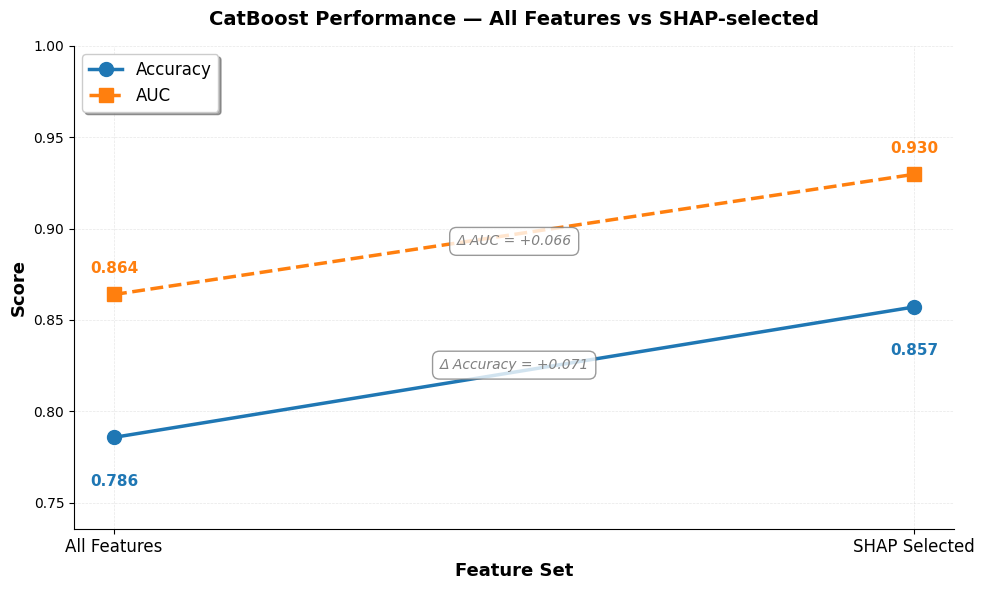


Creating plot for MLP...
✓ Saved: mlp_feature_comparison.png


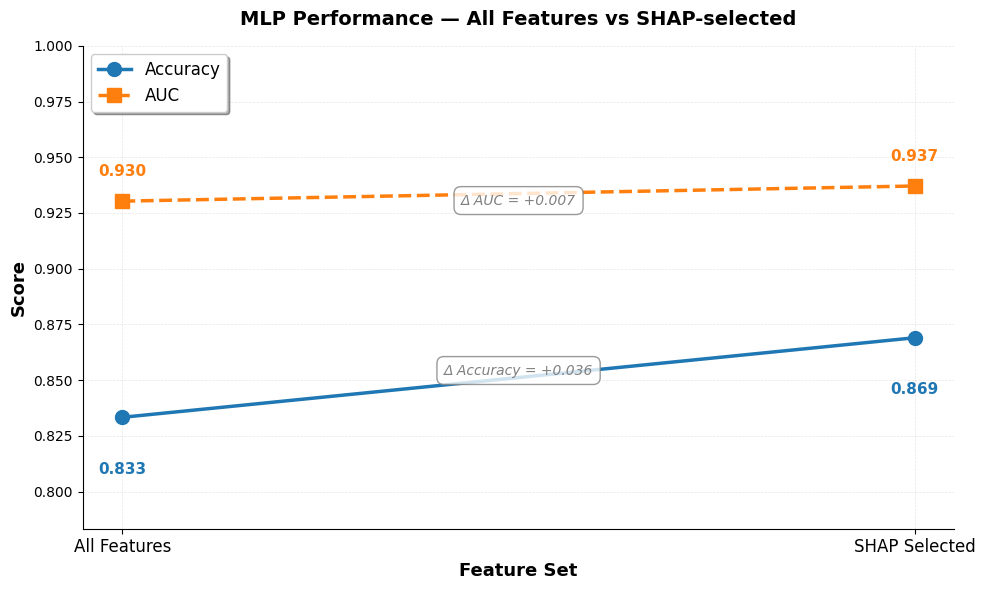


All comparison plots created!


In [ ]:
create_plots_from_df_results(df_results)

In [ ]:
import shutil
from google.colab import files

# Create a zip file of the saved_models folder
shutil.make_archive('saved_models', 'zip', 'saved_models')

# Download the zip file
files.download('saved_models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>